In [1]:
%pip install -qU "langgraph>=0.2.0" langchain-groq langchain-community langgraph-checkpoint-sqlite langchain
%pip install -qU PyMuPDF

# Converting Scanned PDF to PNG

In [2]:
import fitz  # PyMuPDF
import os


In [3]:
def PDF2PNG(file_path):
  doc = fitz.open(file_path)
  png_files = []
  # Create the 'sample' directory if it doesn't exist
  os.makedirs('sample', exist_ok=True)
  for i, page in enumerate(doc):
      pix = page.get_pixmap()
      file_path = f"sample/page_{i}.png"
      pix.save(file_path)   # direct PNG output
      png_files.append(file_path)
  return png_files

In [4]:
ScannedPDF = PDF2PNG("sample_data/LOA7.pdf")

# Extracting Text from Scanned PDFs

In [5]:
pip install pytesseract Pillow

In [6]:
import pytesseract
from PIL import Image
import pandas as pd
from typing import List, Dict

def OCR(image_paths: List[str]) -> Dict:
    results = []
    all_confidences = []  # store all word confidences across pages
    full_text_all_pages = []

    for image_path in image_paths:
        try:
            img = Image.open(image_path)
        except FileNotFoundError:
            print(f"Error: Image file not found at '{image_path}'")
            continue

        # Extract word-level data
        data = pytesseract.image_to_data(
            img, output_type=pytesseract.Output.DATAFRAME
        )

        # Clean data
        cleaned_data = data[
            (data['text'].notna()) &
            (data['text'].str.strip() != '') &
            (data['conf'] != -1)
        ]

        # Collect confidences
        all_confidences.extend(cleaned_data['conf'].tolist())

        # Extract full text
        full_text = pytesseract.image_to_string(img)
        full_text_all_pages.append(full_text.strip())

        # Store per-page result (optional)
        results.append({
            "image_path": image_path,
            "word_count": len(cleaned_data),
            "text": full_text.strip()
        })

    # ✅ Global mean confidence
    if len(all_confidences) > 0:
        global_mean_conf = sum(all_confidences) / len(all_confidences)
    else:
        global_mean_conf = 0.0

    return {
        "global_mean_confidence": round(global_mean_conf, 2),
        "total_words": len(all_confidences),
        "combined_text": "\n".join(full_text_all_pages),
        "pages": results
    }

In [7]:
def TextExtractionFromPDF(file_path):
  png_files = PDF2PNG(file_path)
  return OCR(png_files)

In [8]:
ExtractedText = TextExtractionFromPDF("sample_data/LOA7.pdf")


# Initializing LLM

In [9]:
from langchain_groq import ChatGroq

from google.colab import userdata
import os

os.environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')

In [10]:
llm = ChatGroq(model_name="openai/gpt-oss-120b", temperature=0.7)


# Defining Classification Agent

In [11]:
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain_core.output_parsers import StrOutputParser
import json
import re


In [12]:
SYSTEM_PROMPT = """
You are a document classification agent specialized in legal and financial documents.

Your tasks:

1. LANGUAGE DETECTION
- Identify the primary language of the document.
- Output ONLY one of:
  - "english"
  - "spanish"

2. DOCUMENT CLASSIFICATION
- Determine if the document is a "cease_and_desist" type.
- A cease_and_desist document typically:
  - Requests stopping communication
  - Contains phrases like:
    - "cease and desist"
    - "stop contacting"
    - "cesar y desistir"
    - "dejar de contactar"
  - Mentions legal or financial obligations

- Output ONLY one of:
  - "cease_and_desist"
  - "irrelevant"

---

FINAL OUTPUT FORMAT (STRICT JSON):

{
  "language": "...",
  "document_type": "..."
}

Rules:
- Do NOT include explanations
- Do NOT include extra text
- Be strict and deterministic
"""

In [13]:
def TextClassifier(text):
    messages = [
        SystemMessage(content=SYSTEM_PROMPT),
        HumanMessage(content=text)
    ]
    chain = llm | StrOutputParser()
    response = chain.invoke(messages)

    # extract JSON safely
    json_str = re.search(r"\{.*\}", response, re.DOTALL).group()

    return json.loads(json_str)

In [14]:
TextClassifier(ExtractedText['combined_text'])


{'language': 'spanish', 'document_type': 'cease_and_desist'}

# Logging Results in SQL

In [15]:
import sqlite3

conn = sqlite3.connect("documents.db")
cursor = conn.cursor()

In [16]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS cease_documents (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    date_received TEXT,
    document_name TEXT,
    language TEXT,
    confidence REAL,
    extracted_details TEXT,
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
)
""")

conn.commit()

In [17]:
import json
from datetime import datetime

def store_cease_document(doc_name, language, confidence, extracted_text):

    conn = sqlite3.connect("documents.db")
    cursor = conn.cursor()

    cursor.execute("""
    INSERT INTO cease_documents (
        date_received,
        document_name,
        language,
        confidence,
        extracted_details
    ) VALUES (?, ?, ?, ?, ?)
    """, (
        datetime.now().isoformat(),
        doc_name,
        language,
        confidence,
        extracted_text
    ))

    conn.commit()
    conn.close()

    return {"status": "stored"}

# Archiving Data in Flat File

In [18]:
import json
from datetime import datetime

def archive_document(doc_name, text, confidence):
    file_path = "archive.jsonl"

    new_entry = {
        "datetime": datetime.now().isoformat(),
        "document_name": doc_name,
        "text": text,
        "confidence": confidence
    }

    try:
        with open(file_path, "a", encoding="utf-8") as f:
            f.write(json.dumps(new_entry, ensure_ascii=False) + "\n")
    except Exception as e:
        print(f"Error writing to archive: {e}")
        return {"status": "failed"}

    return {"status": "archived"}

In [19]:
archive_document("LOA7.pdf", ExtractedText['combined_text'], ExtractedText['global_mean_confidence'])


{'status': 'archived'}

Now we have all the necessary Tools and Agents. Now lets create nodes for our Graaph.

# **Building Nodes**
____________________________________________





First lets build the state for our graph.

In [20]:
from langgraph.types import Command
from typing import TypedDict, Optional

class AgentState(TypedDict):
    document_name: str
    text: str
    confidence: float
    language: str
    document_type: str
    human_intervention: bool
    data_storage_location: str




# Document Loader and Text Extractor Node

In [21]:
def ExtractText_Node(state: AgentState):
  print("\n\n___ Extracting Text from PDF ____")
  result = TextExtractionFromPDF(state['document_name'])
  state['confidence'] = result['global_mean_confidence']
  state['text'] = result['combined_text']
  return state

# Classifier Node

In [40]:
def Classifier_Node(state: AgentState):
  print("\n\n___ Classifying Document ____")
  result = TextClassifier(state['text'])
  state['document_type'] = result['document_type']
  state['language'] = result['language']
  print("Document Type: " + state['document_type'])
  print("Language: " + state['language'])
  if(state['confidence']<70):
    state['human_intervention'] = True
  else:
    state['human_intervention'] = False
  return state

# Node to Save Results in Database

In [41]:
def SaveResultsToDB_Node(state: AgentState):
  print("\n\n___ Saving Results to Database ____")
  state['data_storage_location'] = 'database'
  store_cease_document(state['document_name'], state['language'], state['confidence'], state['text'])
  return state

# Node to Archive Data

In [42]:
def ArchiveData_Node(state: AgentState):
  print("\n\n___ Archiving Data ____")
  state['data_storage_location'] = 'archive'
  archive_document(state['document_name'], state['text'], state['confidence'])
  return state

Human In The Loop Node

In [43]:
def Human_Review_Node(state: AgentState):
  print("\n\n___ Human In The Loop ____")
  print("\n Document Name: " + state['document_name'])

  return state

Router after Classification by LLM

In [44]:
def route_after_classification(state: AgentState):
    doc_type = state.get("document_type")
    if state.get("human_intervention"):
        return "hitl"
    elif doc_type == "cease_and_desist":
        return "save"
    elif doc_type == "irrelevant":
        return "archive"

Router after Human Intervention

In [57]:
import builtins

def route_after_hitl(state: AgentState):
    print("\n____________________________________________")
    print("\n___ Human In The Loop ____")
    print("\n____________________________________________")
    print(f"\nDocument Name: {state['document_name']}")
    print("\n-----------------------------------")
    print("Classify this document:")
    print("1 → cease_and_desist")
    print("2 → irrelevant")
    print("-----------------------------------")

    user_input = builtins.input("Enter choice (1 or 2): ").strip()

    if user_input == "1":
        document_type = "cease_and_desist"
        decision = "Cease"
    else:
        document_type = "irrelevant"
        decision = "Irrelevant"
    state['document_type'] = document_type

    if document_type == "cease_and_desist":
        return "save it"
    elif document_type == "irrelevant":
        return "archive it"

# Audit Node

In [65]:
def Audit_Node(state: AgentState):
  print("\n\n___ Auditing __________________________________________________________")
  print("\nDocument Name: " + state['document_name'])
  print("\nDocument Type: " + state['document_type'])
  print("\nLanguage: " + state['language'])
  print("\nConfidence: " + str(state['confidence']))
  print("\nHuman Intervention: " + str(state['human_intervention']))
  print("\nData Storage Location: " + state['data_storage_location'])
  print("\nText: " + state['text'][:500])
  print("\n________________________________________________________________________")
  print("\n\n")
  return state

## Building Graph

In [59]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

In [66]:
builder = StateGraph(AgentState)
builder.add_node("Extract_Text", ExtractText_Node)
builder.add_node("Classify", Classifier_Node)
builder.add_node("Save_Results", SaveResultsToDB_Node)
builder.add_node("Archive_Data", ArchiveData_Node)
builder.add_node("Human_Review", Human_Review_Node)
builder.add_node("Audit", Audit_Node)

builder.add_edge(START, "Extract_Text")
builder.add_edge("Extract_Text", "Classify")
builder.add_conditional_edges(
    "Classify",
    route_after_classification,
    {
        "save": "Save_Results",
        "archive": "Archive_Data",
        "hitl": "Human_Review"
    }
)
builder.add_conditional_edges(
    "Human_Review",
    route_after_hitl,
    {
        "save it": "Save_Results",
        "archive it": "Archive_Data",
    }
)
builder.add_edge("Archive_Data", "Audit")
builder.add_edge("Save_Results", "Audit")
builder.add_edge("Audit", END)

# --- 4. Compile with Interrupt ---
memory = MemorySaver()

# This is the key line: Pause BEFORE executing 'send_email'
graph = builder.compile(checkpointer=memory, interrupt_before=["Human_Review"])

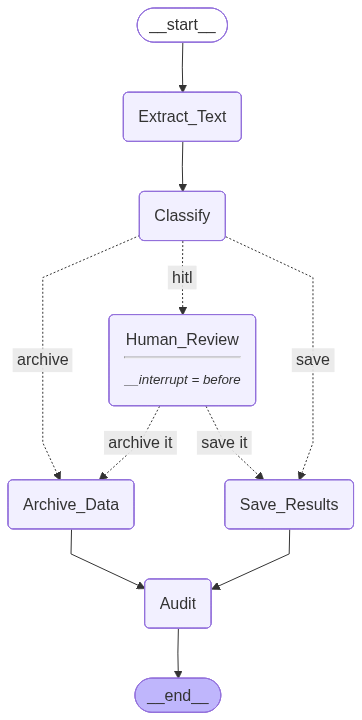

In [71]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [61]:
def Call_Agent(file_path):
  thread_config = {"configurable": {"thread_id": "ticket-123"}}
  stream_input = {
      "document_name": file_path
      }
  for event in graph.stream(stream_input, config=thread_config):
      print(event)
  for event in graph.stream(None, config=thread_config):
    print(event)

**# TESTING THE AGENT**

**Cease and Desist Document Example**

In [67]:
Call_Agent("sample_data/LOA7.pdf")



___ Extracting Text from PDF ____
{'Extract_Text': {'document_name': 'sample_data/LOA7.pdf', 'confidence': 72.08, 'text': 'Anexo C\n\n‘Autorizacién para comunicarse con acreedores y agencias de cobro\nYo (nosotros) autorizo a LAW OFFICES OF DONALD A. GREEN, APLC, 32 DWINELL ST UNIT\n187, BUFFALO, CA incluidos sus agentes, representantes, bogados, socios oterceros\n(CRepresentantes") a realizar las siguientes acciones:\n\n \n\n1. Comunicarse con mis (nuestros) aereedores, incluldos, entre otros, cualquier agente,\nrepresentante o agencia de cobro o bufete de abogados de terceros,y discutir todos los\ndetalles de mi (nuestra) situactn financier todo con el propésito de negociar y ayudar con\nacuerdosy pagos de mis (nuestras) obligaciones de deuda:y\n\n2. Obtener registro, validaciones de deuda, informes de crédito  respaldo de las deudas\nsupuestamenteadeudadas en mi (nuestro) nombre.\n\n‘Ademés, yo (nosotros) instruyo formalmente a todas las partes a cesar y desist de\n‘contactarme (n

**Irrelevant Document Example**

In [68]:
Call_Agent("sample_data/LoA1.pdf")



___ Extracting Text from PDF ____
{'Extract_Text': {'document_name': 'sample_data/LoA1.pdf', 'text': "PINNACLE LAW GROUP.\n\n14 BAYBERRY DRIVE SUITE NO\n48,4SH FLAT,CA\n\nDate: 6/29/2025\n\nAccountReference #:\n\n \n\n‘To Whom It May Concern:\n\n1 (We) have retained the services of PINNACLE LAW GROUP to assist me in\nresolving my debt and have granted it this Limited Power of Attorney. You are\nhereby authorized to release to my attomey and agent, all financial records,\nconfidential and otherwise and other data pertaining to my above-referenced\naccount; review my account history with my attorney; and to discuss my account in\n\nFurther, my agent is authorized to negotiate all matters pertaining to my account; to\n‘make and receive offers of setement; and to reach aj-accord and satisfaction of\n‘ay debts. Please be further advised that I (we) grant to my Agent the full power,\n‘ight, and authority, to do every act, decd, and thing necessary to be done, in order\n‘0 cany out the abov

**Document Classification with Human-In-The-Loop Example**

In [69]:
Call_Agent("sample_data/bw_doc_2.pdf")



___ Extracting Text from PDF ____
{'Extract_Text': {'document_name': 'sample_data/bw_doc_2.pdf', 'text': 'Faulkner, Pierce & Associates ee\n\n \n\n \n\nPopol Semen Decne eat ary\n\n‘<hm dcontanmgeing 9 nd  tinin ae ned\n‘Simm Ky poe nal dtr ee a ny gy', 'confidence': 41.12, 'language': 'english', 'document_type': 'irrelevant', 'human_intervention': False, 'data_storage_location': 'archive'}}


___ Classifying Document ____
Document Type: irrelevant
Language: english
{'Classify': {'document_name': 'sample_data/bw_doc_2.pdf', 'text': 'Faulkner, Pierce & Associates ee\n\n \n\n \n\nPopol Semen Decne eat ary\n\n‘<hm dcontanmgeing 9 nd  tinin ae ned\n‘Simm Ky poe nal dtr ee a ny gy', 'confidence': 41.12, 'language': 'english', 'document_type': 'irrelevant', 'human_intervention': True, 'data_storage_location': 'archive'}}
{'__interrupt__': ()}


___ Human In The Loop ____

 Document Name: sample_data/bw_doc_2.pdf

____________________________________________

___ Human In The Loop ____

___